# El níquel para descarbonizar y los trópicos

> 487 depósitos de níquel mapeados. **El modelo del paper proyecta que entre el 78% y el 83% del níquel extraído hasta 2050 vendrá de lateritas tropicales.** ¿Por qué precisamente esas?

**Paper:** Hyman et al. (2026). *Growing nickel supply from the tropics threatens priority conservation areas*. Nature Ecology & Evolution.
**DOI:** [10.1038/s41559-026-03068-4](https://doi.org/10.1038/s41559-026-03068-4)
**Datos:** Supplementary Data MOESM3 (Springer)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-06-niquel-tropical-conservacion/notebook.ipynb)

**Video:** [Pendiente]


## Lo que vamos a explorar

Los autores construyeron una base mina-por-mina con **487 depósitos** de níquel del mundo (179 lateritas tropicales y 308 sulfuros magmáticos boreales). Sobre ese inventario corrieron PEMMSS, un modelo Monte Carlo que decide qué minas se desarrollan primero según costos, grado y recurso, bajo escenarios de demanda IEA hasta 2050.

Los outputs del modelo (78–83% del suministro futuro proyectado vendría de lateritas, según los escenarios IEA) no los podemos reproducir desde los datos públicos. Pero los **inputs** sí: la geografía, los grados, los tonelajes y los valores de prioridad de biodiversidad. Veamos qué nos dicen sobre por qué el modelo concluye lo que concluye.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TROPICOS_DEG = 23.5              # Latitud que define los trópicos
COSTA_KM = 50                    # Buffer costero usado por el paper (km)
COLOR_LATERITE = '#D97706'       # Naranja tropical
COLOR_SULPHIDE = '#2563EB'       # Azul boreal
COLOR_REFERENCIA = '#7C3AED'     # Violeta para zonas críticas
COLOR_ANOTACION = '#DC2626'      # Rojo para anotaciones de énfasis
FUENTE = 'Fuente: Hyman et al. (2026), Nature Ecology & Evolution | Datos: Supplementary Data MOESM3'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

# Cargar estilo CaM (local → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# Cargar datos
df = pd.read_csv('datos/minas_niquel_PEMMSS.csv')
df['GRADE_PCT'] = df['GRADE'] * 100  # GRADE viene como decimal en el CSV
df['RESOURCE_MT'] = df['REMAINING_RESOURCE'] / 1e6  # Mt mineral
df['ABS_LAT'] = df['LATITUDE'].abs()
df['ES_TROPICAL'] = df['ABS_LAT'] <= TROPICOS_DEG

print(f'Total depósitos: {len(df)}')
print(f'  - Laterita: {(df.DEPOSIT_TYPE == "Laterite").sum()}')
print(f'  - Sulfuro magmático: {(df.DEPOSIT_TYPE == "Magmatic Sulphide").sum()}')
print(f'Operando hoy (STATUS=1): {(df.STATUS == 1).sum()}')
print(f'En trópicos (|lat| ≤ {TROPICOS_DEG}°): {df.ES_TROPICAL.sum()}')


Total depósitos: 487
  - Laterita: 179
  - Sulfuro magmático: 308
Operando hoy (STATUS=1): 115
En trópicos (|lat| ≤ 23.5°): 158


## Aquí está. La geografía del níquel.

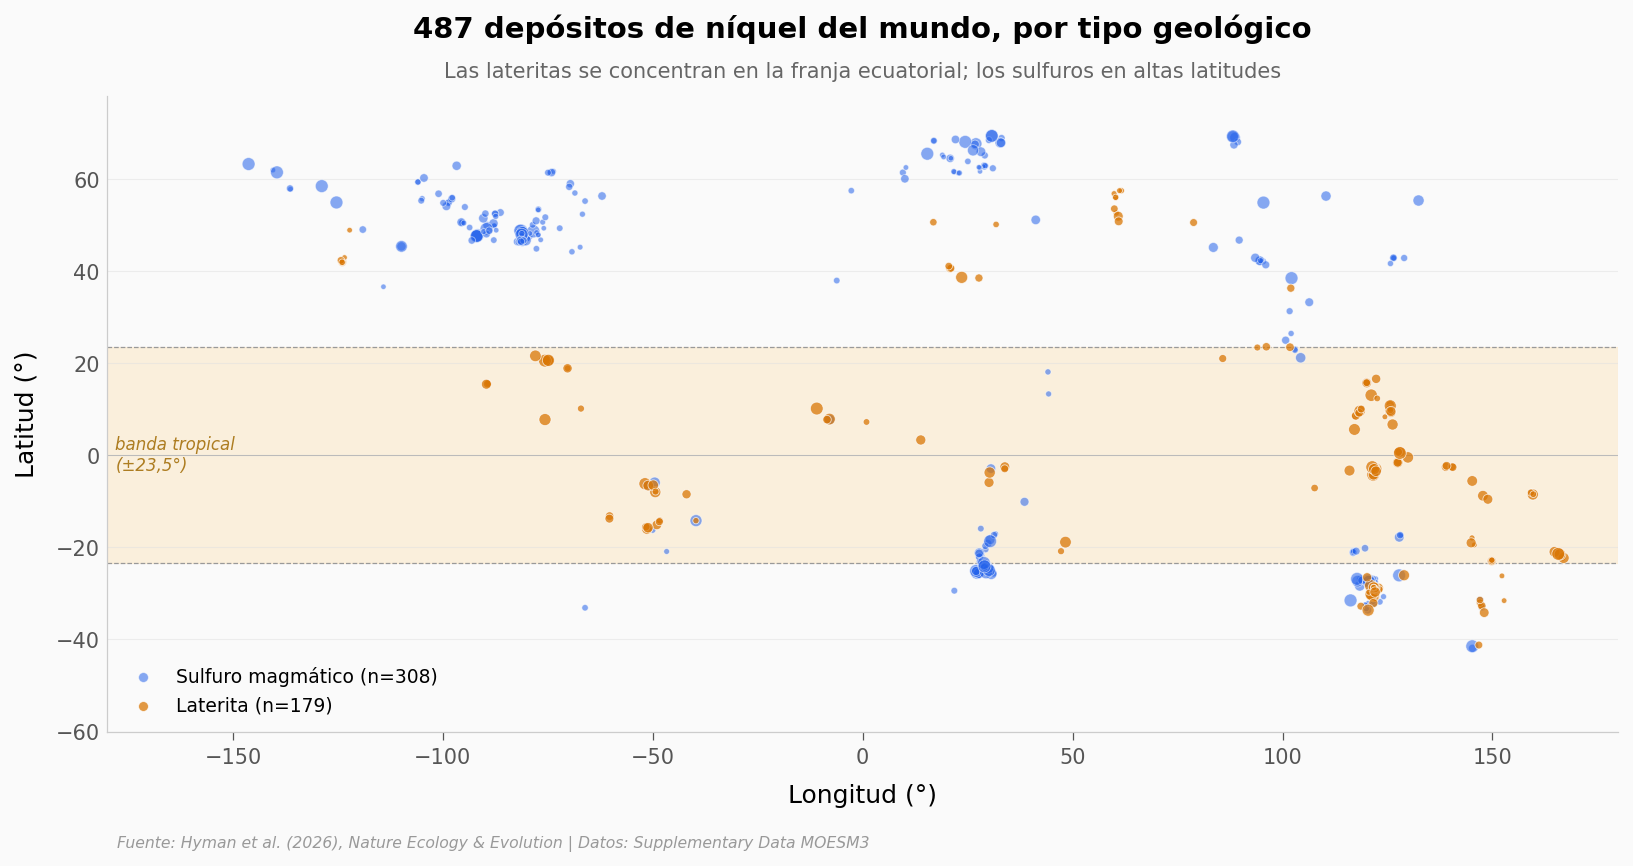

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

lat_df = df[df.DEPOSIT_TYPE == 'Laterite']
sul_df = df[df.DEPOSIT_TYPE == 'Magmatic Sulphide']

# Banda de trópicos sombreada
ax.axhspan(-TROPICOS_DEG, TROPICOS_DEG, color='#FBE8C8', alpha=0.6, zorder=1)
ax.axhline(y=TROPICOS_DEG, color='#999999', linewidth=0.6, linestyle='--', zorder=2)
ax.axhline(y=-TROPICOS_DEG, color='#999999', linewidth=0.6, linestyle='--', zorder=2)
ax.axhline(y=0, color='#bbbbbb', linewidth=0.5, zorder=2)

# Tamaño de marcador escalado por sqrt(recurso) para que se vea sin exagerar
size_lat = 6 + 1.6 * np.sqrt(lat_df.RESOURCE_MT.clip(upper=400))
size_sul = 6 + 1.6 * np.sqrt(sul_df.RESOURCE_MT.clip(upper=400))

ax.scatter(sul_df.LONGITUDE, sul_df.LATITUDE, s=size_sul,
           color=COLOR_SULPHIDE, alpha=0.55, edgecolors='white',
           linewidths=0.4, zorder=4, label='Sulfuro magmático (n=308)')
ax.scatter(lat_df.LONGITUDE, lat_df.LATITUDE, s=size_lat,
           color=COLOR_LATERITE, alpha=0.75, edgecolors='white',
           linewidths=0.4, zorder=5, label='Laterita (n=179)')

# Anotación de la banda tropical
ax.text(-178, 0, 'banda tropical\n(±23,5°)', fontsize=8, color='#a06900',
        ha='left', va='center', style='italic', alpha=0.85)

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 78)
ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
ax.set_title('487 depósitos de níquel del mundo, por tipo geológico',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las lateritas se concentran en la franja ecuatorial; los sulfuros en altas latitudes',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='lower left', framealpha=0.92)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_mapa_minas.png', dpi=200, bbox_inches='tight')
plt.show()


La separación geográfica es nítida. Las lateritas se acumulan a ambos lados del ecuador — Indonesia, Filipinas, Cuba, Nueva Caledonia, África ecuatorial, parte de Australia tropical. Los sulfuros magmáticos viven mayoritariamente arriba: el escudo canadiense, Rusia, Escandinavia.

En números: **el 67% de las lateritas caen en los trópicos (|lat| ≤ 23,5°)**, contra el **12% de los sulfuros**. La mediana de latitud es **−1,4°** para lateritas y **+46,4°** para sulfuros. No es un sesgo de muestreo: es la geología. Las lateritas se forman por meteorización tropical intensa de rocas ultramáficas, y eso solo ocurre cerca del ecuador.

## Pero el mapa esconde algo más

El paper marca cada mina con un valor de **prioridad marina** si está dentro de 50 km del mar. Esa columna nos sirve como proxy para saber cuántas minas son costeras.

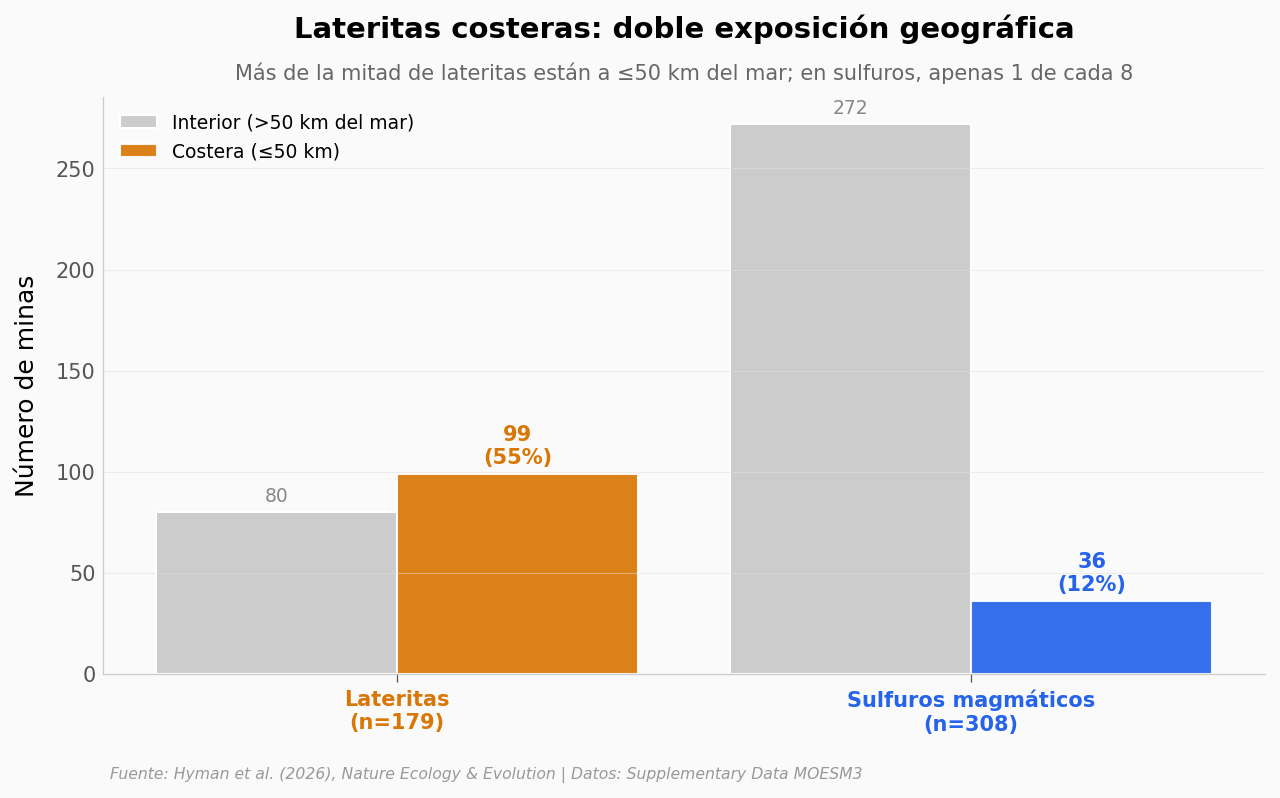

In [3]:
# Costera = tiene valor MARINE_BIODIVERSITY_50KM_VALUE no nulo
df['COSTERA'] = df['MARINE_BIODIVERSITY_50KM_VALUE'].notna()

split = (df.groupby('DEPOSIT_TYPE')['COSTERA']
           .agg(['sum', 'count'])
           .rename(columns={'sum': 'costeras', 'count': 'total'}))
split['interior'] = split['total'] - split['costeras']
split['pct_costera'] = 100 * split['costeras'] / split['total']

fig, ax = plt.subplots(figsize=(10, 5))

groups = ['Laterite', 'Magmatic Sulphide']
labels_es = ['Lateritas\n(n=179)', 'Sulfuros magmáticos\n(n=308)']
colors = [COLOR_LATERITE, COLOR_SULPHIDE]

x = np.arange(len(groups))
width = 0.42

interior_vals = [split.loc[g, 'interior'] for g in groups]
costera_vals = [split.loc[g, 'costeras'] for g in groups]

bars_int = ax.bar(x - width/2, interior_vals, width,
                  color='#cccccc', edgecolor='white', linewidth=1,
                  label=f'Interior (>{COSTA_KM} km del mar)')
bars_cos = ax.bar(x + width/2, costera_vals, width,
                  color=colors, edgecolor='white', linewidth=1,
                  alpha=0.92, label=f'Costera (≤{COSTA_KM} km)')

# Etiquetas con conteo y porcentaje sobre las barras costeras
for i, g in enumerate(groups):
    cos = split.loc[g, 'costeras']
    pct = split.loc[g, 'pct_costera']
    ax.text(i + width/2, cos + 5, f'{int(cos)}\n({pct:.0f}%)',
            ha='center', fontsize=10, fontweight='bold',
            color=colors[i])
    intr = split.loc[g, 'interior']
    ax.text(i - width/2, intr + 5, f'{int(intr)}',
            ha='center', fontsize=9, color='#888888')

ax.set_xticks(x)
ax.set_xticklabels(labels_es, fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colors):
    tick.set_color(color)
ax.set_ylabel('Número de minas')
ax.set_title('Lateritas costeras: doble exposición geográfica',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Más de la mitad de lateritas están a ≤{COSTA_KM} km del mar; en sulfuros, apenas 1 de cada 8',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper left', framealpha=0.92)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_costera_vs_interior.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Por qué PEMMSS las elige primero?

El modelo no es ideológico: prioriza minas según economía. Una mina con grado más alto y más mineral disponible es más rentable. Si las lateritas dominan el suministro proyectado, debe haber una razón competitiva que las haga atractivas frente a los sulfuros boreales.

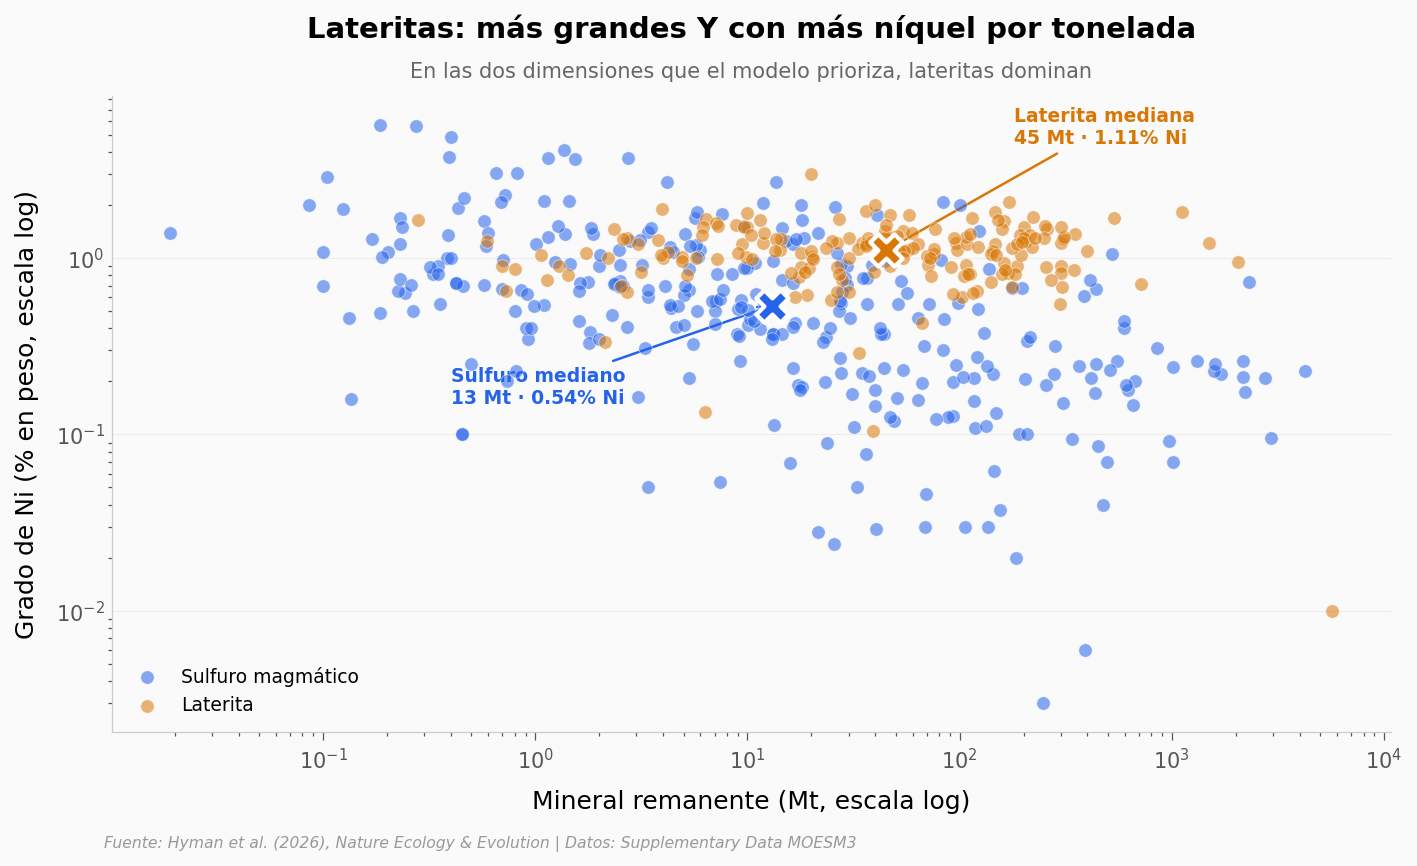

Mediana grado laterita: 1.11% Ni
Mediana grado sulfuro:  0.54% Ni
Mediana mineral laterita: 44.9 Mt
Mediana mineral sulfuro:  13.1 Mt


In [4]:
# Filtrar valores válidos para log-scale
mask = (df.GRADE_PCT > 0) & (df.RESOURCE_MT > 0)
sub = df[mask].copy()

fig, ax = plt.subplots(figsize=(11, 5.5))

for dep, color, label in [
    ('Magmatic Sulphide', COLOR_SULPHIDE, 'Sulfuro magmático'),
    ('Laterite', COLOR_LATERITE, 'Laterita'),
]:
    g = sub[sub.DEPOSIT_TYPE == dep]
    ax.scatter(g.RESOURCE_MT, g.GRADE_PCT, s=42,
               color=color, alpha=0.55, edgecolors='white',
               linewidths=0.4, label=label, zorder=4)

# Anotar las medianas como líneas suaves
med_lat_grade = sub[sub.DEPOSIT_TYPE == 'Laterite'].GRADE_PCT.median()
med_sul_grade = sub[sub.DEPOSIT_TYPE == 'Magmatic Sulphide'].GRADE_PCT.median()
med_lat_res = sub[sub.DEPOSIT_TYPE == 'Laterite'].RESOURCE_MT.median()
med_sul_res = sub[sub.DEPOSIT_TYPE == 'Magmatic Sulphide'].RESOURCE_MT.median()

ax.scatter([med_lat_res], [med_lat_grade], marker='X', s=240,
           color=COLOR_LATERITE, edgecolors='white', linewidths=2, zorder=6)
ax.scatter([med_sul_res], [med_sul_grade], marker='X', s=240,
           color=COLOR_SULPHIDE, edgecolors='white', linewidths=2, zorder=6)
ax.annotate(f'Laterita mediana\n{med_lat_res:.0f} Mt · {med_lat_grade:.2f}% Ni',
            xy=(med_lat_res, med_lat_grade), xytext=(180, 4.5),
            fontsize=9, fontweight='bold', color=COLOR_LATERITE,
            arrowprops=dict(arrowstyle='->', color=COLOR_LATERITE, lw=1.2))
ax.annotate(f'Sulfuro mediano\n{med_sul_res:.0f} Mt · {med_sul_grade:.2f}% Ni',
            xy=(med_sul_res, med_sul_grade), xytext=(0.4, 0.15),
            fontsize=9, fontweight='bold', color=COLOR_SULPHIDE,
            arrowprops=dict(arrowstyle='->', color=COLOR_SULPHIDE, lw=1.2))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Mineral remanente (Mt, escala log)')
ax.set_ylabel('Grado de Ni (% en peso, escala log)')
ax.set_title('Lateritas: más grandes Y con más níquel por tonelada',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'En las dos dimensiones que el modelo prioriza, lateritas dominan',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='lower left', framealpha=0.92)

fig.text(0.12, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_grado_vs_recurso.png', dpi=200, bbox_inches='tight')
plt.show()

# Reportar números clave para la narrativa
print(f'Mediana grado laterita: {med_lat_grade:.2f}% Ni')
print(f'Mediana grado sulfuro:  {med_sul_grade:.2f}% Ni')
print(f'Mediana mineral laterita: {med_lat_res:.1f} Mt')
print(f'Mediana mineral sulfuro:  {med_sul_res:.1f} Mt')


## ¿Y la biodiversidad terrestre?

Cada mina tiene un **valor de prioridad terrestre** (TBCV): un percentil global 1–98 derivado del mapa de Jung et al. (2021), que combina biodiversidad y carbono almacenado. Cuanto más alto el rank, más crítica la celda. Veamos cómo se distribuyen los 487 depósitos.

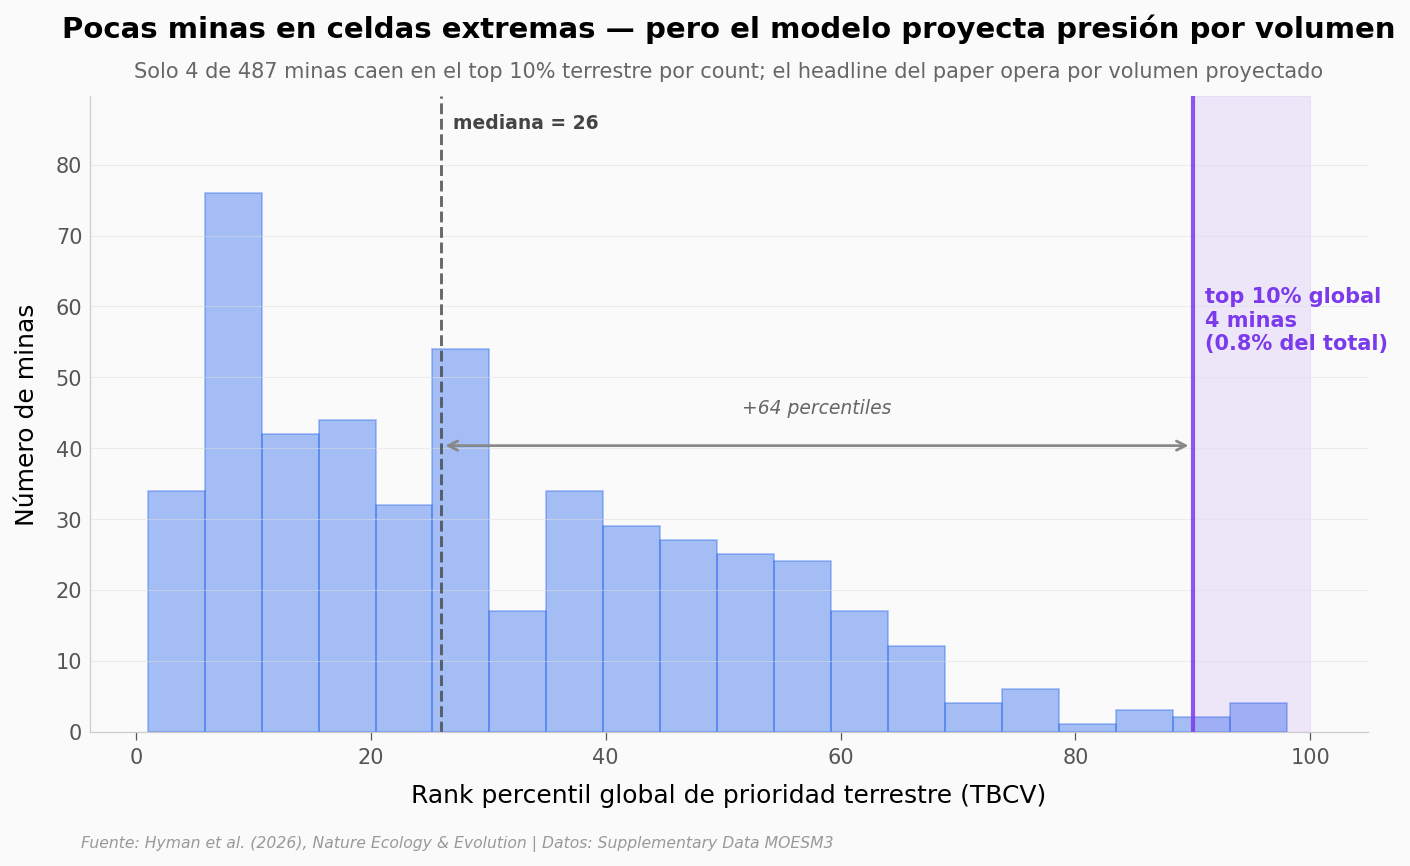

TBCV mediana: 26.0
Minas en top 10% global (rank ≥ 90): 4 (0.82%)


In [5]:
tbcv = df['TERRESTRIAL_BIODIVERSITY_CARBON_VALUE'].dropna()

fig, ax = plt.subplots(figsize=(11, 5.5))

n, bins, patches = ax.hist(tbcv, bins=20, color=COLOR_SULPHIDE,
                           alpha=0.4, edgecolor=COLOR_SULPHIDE, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Mediana global
med = tbcv.median()
ax.axvline(x=med, color='#444444', linewidth=1.4, linestyle='--', alpha=0.8)
ax.text(med + 1, y_max * 0.95, f'mediana = {med:.0f}',
        fontsize=9, color='#444444', fontweight='bold')

# Línea del top 10% (rank ≥ 90)
top10 = 90
ax.axvline(x=top10, color=COLOR_REFERENCIA, linewidth=2, linestyle='-', alpha=0.85)
ax.axvspan(top10, 100, color=COLOR_REFERENCIA, alpha=0.10)

# Conteo en top 10%
top10_count = (tbcv >= top10).sum()
ax.text(top10 + 1, y_max * 0.7, f'top 10% global\n{top10_count} minas\n({top10_count/len(tbcv)*100:.1f}% del total)',
        fontsize=10, color=COLOR_REFERENCIA, fontweight='bold', va='top')

# Flecha bidireccional mediana → top10
ax.annotate('', xy=(top10, y_max*0.45), xytext=(med, y_max*0.45),
            arrowprops=dict(arrowstyle='<->', color='#888888', lw=1.3))
ax.text((med + top10)/2, y_max*0.50, f'+{top10-med:.0f} percentiles',
        fontsize=9, color='#666666', ha='center', style='italic')

ax.set_xlabel('Rank percentil global de prioridad terrestre (TBCV)')
ax.set_ylabel('Número de minas')
ax.set_title('Pocas minas en celdas extremas — pero el modelo proyecta presión por volumen',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Solo 4 de 487 minas caen en el top 10% terrestre por count; el headline del paper opera por volumen proyectado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.12, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_tbcv_histograma.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'TBCV mediana: {med:.1f}')
print(f'Minas en top 10% global (rank ≥ 90): {top10_count} ({top10_count/len(tbcv)*100:.2f}%)')


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Las lateritas son tropicales y los sulfuros boreales | ✅ | Mediana lat: lateritas −1,4°, sulfuros +46,4°. 67% de lateritas en \|lat\| ≤ 23,5°; 12% de sulfuros. Patrón nítido en el mapa. |
| Las lateritas son desproporcionadamente costeras | ✅ | 55% de lateritas a ≤50 km del mar, contra 12% de sulfuros. Doble exposición (terrestre + marina) confirmada en los inputs. |
| Las lateritas tienen mayor grado y mayor recurso | ✅ | Mediana grado: 1,11% Ni vs 0,54%. Mediana mineral remanente: 45 Mt vs 13 Mt. Coherente con que PEMMSS las priorice por economía. |
| ~80% del suministro 2025–2050 saldrá de lateritas | ⚠️ | Es un OUTPUT del modelo (78–83%), no reproducible desde los inputs. Nuestro share equivalente desde la base es 63% del Ni contenido — el modelo amplifica esa ventaja al ponderar por economía. Lo enmarcamos como proyección, no observación. |
| La mitad del suministro amenaza el top 10% terrestre | ⚠️ | Headline del paper, también OUTPUT. Por count, solo 4 de 487 minas (0,8%) están en celdas con TBCV ≥ 90; el paper habla de volumen proyectado, no de count de minas. Son métricas distintas — no confundirlas. |
| Las lateritas son siempre la peor opción biodiversidad | ❌ | NO soportado. La mediana de TBCV es **mayor** en sulfuros (28 vs 18; Mann-Whitney U=21.780, p<0,001, n=179 vs 308; Cohen's d=−0,30, efecto pequeño-moderado). El conflicto tropical-laterítico se materializa por volumen y por la dimensión marina, no por el rank terrestre puntual. |

> **Limitaciones:**
> - Los outputs del modelo PEMMSS (78–83%, 53–60% costero, "mitad amenaza top 10%") **no son reproducibles** desde los inputs públicos sin correr el modelo Monte Carlo completo.
> - Los datos son una base de proyectos (S&P Capital IQ + literatura), no un censo: minas no documentadas no aparecen.
> - El TBCV es un percentil global derivado de un raster a 10 km de resolución (Jung et al. 2021); los valores puntuales tienen incertidumbre por la asignación celda-a-mina.
> - El paper modela escenarios (IEA APS/STEPS/NZE), no observa el futuro. "El modelo proyecta" ≠ "esto va a pasar".

## Ahora tú

1. **¿Cómo cambia el cuadro si reduces el buffer costero a 25 km?** — modifica `COSTA_KM` arriba y vuelve a calcular el split. Pista: la columna `MARINE_BIODIVERSITY_50KM_VALUE` ya está fijada a 50 km, así que tendrás que filtrar por proximidad usando lat/lon (haversine).
2. **¿Qué países concentran las lateritas tropicales?** — agrupa por bounding boxes (Indonesia ~ lat −10 a 5, lon 95 a 141; Filipinas ~ lat 5 a 19, lon 117 a 127; Nueva Caledonia ~ lat −22.7 a −19.5, lon 163 a 168) y cuenta minas tropicales por país.
3. **¿Qué pasa con las minas que ya están operando hoy (`STATUS == 1`)?** — repite el split tropical/no-tropical solo para las 115 minas activas. ¿La presión actual ya muestra el sesgo tropical, o todavía es una proyección a futuro?

```python
# Pista para la pregunta 3
activas = df[df.STATUS == 1]
print(activas.groupby(['DEPOSIT_TYPE', 'ES_TROPICAL']).size())
```

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Cuántas minas activas hay por tipo y por trópico
activas = df[df.STATUS == 1]
print(f'Minas operando hoy: {len(activas)}')
print()
print('Desglose por tipo y trópico:')
print(activas.groupby(['DEPOSIT_TYPE', 'ES_TROPICAL']).size().unstack(fill_value=0))
print()
print('% tropical dentro de cada tipo (operando hoy):')
print((activas.groupby('DEPOSIT_TYPE')['ES_TROPICAL'].mean() * 100).round(1))


Minas operando hoy: 115

Desglose por tipo y trópico:
ES_TROPICAL        False  True 
DEPOSIT_TYPE                   
Laterite               8     46
Magmatic Sulphide     46     15

% tropical dentro de cada tipo (operando hoy):
DEPOSIT_TYPE
Laterite             85.2
Magmatic Sulphide    24.6
Name: ES_TROPICAL, dtype: float64


## Créditos

- **Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Sitio:** [cienciaamordiscos.com](https://cienciaamordiscos.com)
- **Licencia:** notebook MIT, datos según licencia original del paper (Springer Nature, Supplementary Materials).

## Fuentes

**Paper**: [Growing nickel supply from the tropics threatens priority conservation areas](https://doi.org/10.1038/s41559-026-03068-4)  
*Nature Ecology & Evolution, 2026-05-06*

**Supplementary Material**: [PEMMSS input files (MOESM3)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41559-026-03068-4/MediaObjects/41559_2026_3068_MOESM3_ESM.zip)

**Dataset terrestre**: [Areas of global importance for conserving terrestrial biodiversity, carbon and water](https://doi.org/10.5281/zenodo.5006332)  
*Jung et al. (2021), valores TBCV de prioridad terrestre*

**Dataset marino**: [Protecting the global ocean for biodiversity, food and climate](https://doi.org/10.25349/D9N89M)  
*Sala et al. (2021), valores de prioridad marina (buffer 50 km)*

**Modelo citado**: [PEMMSS v1.4.0 (código)](https://doi.org/10.5281/zenodo.16792366) — Northey et al., Zenodo.

*21 afirmaciones del notebook verificadas contra estas fuentes*
